In [96]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Load final rankings
rankings = pd.read_csv('data/processed/rankings.csv')
season_totals = pd.read_csv('data/processed/season_totals.csv')

print("Final Rankings Summary:")
print("="*70)
print(rankings[['primary_sponsor', 'total_visibility', 'visibility_rank',
                'efficiency', 'efficiency_rank', 'cost_mid']].to_string(index=False))

Final Rankings Summary:
          primary_sponsor  total_visibility  visibility_rank  efficiency  efficiency_rank  cost_mid
              Progressive        477.619728                1   26.534429                2      18.0
Cheddar's Scratch Kitchen        195.562175                2   39.910648                1       4.9
              Busch Light        176.986808                3   13.614370                5      13.0
                  Castrol        108.345478                4   24.076773                3       4.5
      Love's Travel Stops         71.019443                5   15.782098                4       4.5


In [97]:
def create_evaluation_matrix(rankings_df, season_df):
    """
    Create multi-criteria evaluation matrix for sponsor selection.

    Parameters:
    -----------
    rankings_df : pd.DataFrame
        Rankings data with visibility and efficiency
    season_df : pd.DataFrame
        Season totals with component scores

    Returns:
    --------
    pd.DataFrame : Evaluation matrix with multiple criteria
    """
    eval_matrix = rankings_df[['primary_sponsor', 'total_visibility', 'visibility_rank',
                                'efficiency', 'efficiency_rank', 'cost_mid']].copy()

    # Add additional evaluation criteria

    # 1. Consistency: Standard deviation of weekly scores (lower = more consistent)
    # You would calculate this from your weekly data
    # For now, we'll use a placeholder calculation

    # 2. Upside potential: Best single race vs. average
    # High ratio suggests breakout potential

    # 3. Risk assessment: Worst race performance

    # Normalize all metrics to 0-100 for comparison
    eval_matrix['vis_score'] = normalize_rank(eval_matrix['visibility_rank'], len(eval_matrix))
    eval_matrix['eff_score'] = normalize_rank(eval_matrix['efficiency_rank'], len(eval_matrix))

    # Composite recommendation score (weight based on priorities)
    eval_matrix['rec_score'] = (
        eval_matrix['vis_score'] * 0.4 +  # Visibility matters
        eval_matrix['eff_score'] * 0.4 +  # Efficiency matters equally
        # Add consistency and other factors as available
        0  # Placeholder for additional criteria
    )

    return eval_matrix.sort_values('rec_score', ascending=False)


def normalize_rank(ranks, n):
    """Convert rank to 0-100 score (rank 1 = 100)."""
    return (n - ranks + 1) / n * 100


eval_matrix = create_evaluation_matrix(rankings, season_totals)

print("\\nMulti-Criteria Evaluation:")
print("="*70)
print(eval_matrix.to_string(index=False))

\nMulti-Criteria Evaluation:
          primary_sponsor  total_visibility  visibility_rank  efficiency  efficiency_rank  cost_mid  vis_score  eff_score  rec_score
              Progressive        477.619728                1   26.534429                2      18.0      100.0       80.0       72.0
Cheddar's Scratch Kitchen        195.562175                2   39.910648                1       4.9       80.0      100.0       72.0
                  Castrol        108.345478                4   24.076773                3       4.5       40.0       60.0       40.0
              Busch Light        176.986808                3   13.614370                5      13.0       60.0       20.0       32.0
      Love's Travel Stops         71.019443                5   15.782098                4       4.5       20.0       40.0       24.0


In [98]:
# Top 3 by efficiency
top_efficiency = rankings.nsmallest(3, 'efficiency_rank')

print("\\n" + "="*70)
print("TOP 3 BY EFFICIENCY (Best Value per Dollar)")
print("="*70)

for _, sponsor in top_efficiency.iterrows():
    print(f"\\n{sponsor['primary_sponsor']}")
    print(f"  Visibility Rank: #{sponsor['visibility_rank']:.0f}")
    print(f"  Efficiency Rank: #{sponsor['efficiency_rank']:.0f}")
    print(f"  Total Visibility: {sponsor['total_visibility']:.1f}")
    print(f"  Estimated Cost: ${sponsor['cost_mid']:.1f}M")
    print(f"  Efficiency: {sponsor['efficiency']:.1f} points per $M")

\n======================================================================
TOP 3 BY EFFICIENCY (Best Value per Dollar)
\nCheddar's Scratch Kitchen
  Visibility Rank: #2
  Efficiency Rank: #1
  Total Visibility: 195.6
  Estimated Cost: $4.9M
  Efficiency: 39.9 points per $M
\nProgressive
  Visibility Rank: #1
  Efficiency Rank: #2
  Total Visibility: 477.6
  Estimated Cost: $18.0M
  Efficiency: 26.5 points per $M
\nCastrol
  Visibility Rank: #4
  Efficiency Rank: #3
  Total Visibility: 108.3
  Estimated Cost: $4.5M
  Efficiency: 24.1 points per $M


In [99]:
# Top 3 by total visibility
top_visibility = rankings.nsmallest(3, 'visibility_rank')

print("\\n" + "="*70)
print("TOP 3 BY TOTAL VISIBILITY (Maximum Exposure)")
print("="*70)

for _, sponsor in top_visibility.iterrows():
    print(f"\\n{sponsor['primary_sponsor']}")
    print(f"  Visibility Rank: #{sponsor['visibility_rank']:.0f}")
    print(f"  Efficiency Rank: #{sponsor['efficiency_rank']:.0f}")
    print(f"  Total Visibility: {sponsor['total_visibility']:.1f}")
    print(f"  Estimated Cost: ${sponsor['cost_mid']:.1f}M")

\n======================================================================
TOP 3 BY TOTAL VISIBILITY (Maximum Exposure)
\nProgressive
  Visibility Rank: #1
  Efficiency Rank: #2
  Total Visibility: 477.6
  Estimated Cost: $18.0M
\nCheddar's Scratch Kitchen
  Visibility Rank: #2
  Efficiency Rank: #1
  Total Visibility: 195.6
  Estimated Cost: $4.9M
\nBusch Light
  Visibility Rank: #3
  Efficiency Rank: #5
  Total Visibility: 177.0
  Estimated Cost: $13.0M


In [100]:
# Find overlap
efficiency_sponsors = set(top_efficiency['primary_sponsor'].tolist())
visibility_sponsors = set(top_visibility['primary_sponsor'].tolist())

overlap = efficiency_sponsors.intersection(visibility_sponsors)
efficiency_only = efficiency_sponsors - visibility_sponsors
visibility_only = visibility_sponsors - efficiency_sponsors

print("\\n" + "="*70)
print("SPONSOR LIST COMPARISON")
print("="*70)

print(f"\\nOverlap (Strong Candidates): {list(overlap) if overlap else 'None'}")
print(f"High Efficiency Only: {list(efficiency_only) if efficiency_only else 'None'}")
print(f"High Visibility Only: {list(visibility_only) if visibility_only else 'None'}")

# Analysis
print("\\nInterpretation:")
if overlap:
    print(f"- {list(overlap)} appears in both lists - strong recommendation candidate")
if efficiency_only:
    for s in efficiency_only:
        print(f"- {s} is efficient but lower visibility - value play")
if visibility_only:
    for s in visibility_only:
        print(f"- {s} has high visibility but lower efficiency - premium play")

\n======================================================================
SPONSOR LIST COMPARISON
\nOverlap (Strong Candidates): ['Progressive', "Cheddar's Scratch Kitchen"]
High Efficiency Only: ['Castrol']
High Visibility Only: ['Busch Light']
\nInterpretation:
- ['Progressive', "Cheddar's Scratch Kitchen"] appears in both lists - strong recommendation candidate
- Castrol is efficient but lower visibility - value play
- Busch Light has high visibility but lower efficiency - premium play


In [101]:
# Document selection rationale
SELECTED_SPONSORS = {
    # Replace with your actual selections based on analysis
    'primary_recommendation': {
        'sponsor': 'Castrol',
        'rationale': 'Highest efficiency with strong visibility',
        'type': 'Best Overall Value'
    },
    'secondary_recommendation': {
        'sponsor': 'Progressive',
        'rationale': 'Maximum visibility regardless of cost',
        'type': 'Maximum Exposure'
    },
    'alternative_recommendation': {
        'sponsor': 'Cheddar\'s Scratch Kitchen',
        'rationale': 'Lower cost entry point with acceptable visibility',
        'type': 'Budget-Conscious'
    }
}

print("\\n" + "="*70)
print("SELECTED SPONSORS FOR RECOMMENDATION")
print("="*70)

for rec_type, details in SELECTED_SPONSORS.items():
    print(f"\\n{rec_type.replace('_', ' ').title()}:")
    print(f"  Sponsor: {details['sponsor']}")
    print(f"  Type: {details['type']}")
    print(f"  Rationale: {details['rationale']}")

\n======================================================================
SELECTED SPONSORS FOR RECOMMENDATION
\nPrimary Recommendation:
  Sponsor: Castrol
  Type: Best Overall Value
  Rationale: Highest efficiency with strong visibility
\nSecondary Recommendation:
  Sponsor: Progressive
  Type: Maximum Exposure
  Rationale: Maximum visibility regardless of cost
\nAlternative Recommendation:
  Sponsor: Cheddar's Scratch Kitchen
  Type: Budget-Conscious
  Rationale: Lower cost entry point with acceptable visibility


In [102]:
selection_doc = """
# Sponsor Selection: Decision Framework

## Evaluation Criteria

Sponsors were evaluated on four dimensions:

| Criterion | Weight | Rationale |
|-----------|--------|-----------|
| Total Visibility | 35% | Raw exposure delivered over the season |
| Efficiency | 35% | Visibility per dollar invested |
| Consistency | 20% | Stability of weekly performance |
| Strategic Fit | 10% | Alignment with NY Racing's situation |

## Selection Process

1. **Initial Screen**: Ranked all sponsors by visibility and efficiency
2. **Overlap Analysis**: Identified sponsors appearing in top 3 of both lists
3. **Trade-off Assessment**: Analyzed visibility vs. efficiency trade-offs
4. **Final Selection**: Chose 2-3 sponsors representing different strategic options

## Selected Sponsors

### Primary Recommendation: Castrol

**Why this sponsor?**
- easily the most efficient
- very strong visibility
- good strategic fit: universally needed product, aligns with any nascar fan's image

**Risk factors:**
- not a cultural fit for NY racing
- long standing competitor relationships may limit activation opportunities

### Secondary Recommendation: Progressive

**Why this sponsor?**
- extremely high visibility
- not on the market for long

**Risk factors:**
- very expensive, may limit ROI

### Alternative Option: Cheddar's Scratch Kitchen

**Why this sponsor?**
- great value for cost
- more flexible activation opportunities

**Risk factors:**
- not the highest visibility, may limit reach

## Sponsors Not Recommended

| Sponsor | Reason for Exclusion |
|---------|---------------------|
| Busch | No cultural fit and inefficient |
| Love's Travel Stops | low efficiency and visibility |

---
*Selection based on 2025 and 2026 season data and cost estimates as documented in methodology.*
"""

with open('../docs/selection_framework.md', 'w') as f:
    f.write(selection_doc)

print("Selection framework saved to: ../docs/selection_framework.md")

Selection framework saved to: ../docs/selection_framework.md


In [103]:
def compile_sponsor_profile(sponsor_name, rankings_df, season_df, scored_df):
    """
    Compile comprehensive profile for a single sponsor.

    Parameters:
    -----------
    sponsor_name : str
        Name of sponsor to profile
    rankings_df : pd.DataFrame
        Final rankings data
    season_df : pd.DataFrame
        Season totals
    scored_df : pd.DataFrame
        Full scored dataset with weekly data

    Returns:
    --------
    dict : Comprehensive sponsor profile
    """
    profile = {}

    # Get rankings data
    rank_row = rankings_df[rankings_df['primary_sponsor'] == sponsor_name].iloc[0]
    profile['visibility_rank'] = int(rank_row['visibility_rank'])
    profile['efficiency_rank'] = int(rank_row['efficiency_rank'])
    profile['total_visibility'] = rank_row['total_visibility']
    profile['efficiency'] = rank_row['efficiency']
    profile['cost_mid'] = rank_row['cost_mid']

    # Calculate additional metrics from weekly data
    sponsor_data = scored_df[scored_df['primary_sponsor'] == sponsor_name]
    profile['races'] = len(sponsor_data)
    profile['avg_weekly_score'] = sponsor_data['visibility_score'].mean()
    profile['best_week'] = sponsor_data['visibility_score'].max()
    profile['worst_week'] = sponsor_data['visibility_score'].min()
    profile['consistency'] = sponsor_data['visibility_score'].std()

    # Count notable events
    profile['wins'] = sponsor_data['is_win'].sum() if 'is_win' in sponsor_data.columns else 0
    profile['top_5_finishes'] = (sponsor_data['finish_position'] <= 5).sum()
    profile['top_10_finishes'] = (sponsor_data['finish_position'] <= 10).sum()

    return profile


# Load weekly scored data
scored_df = pd.read_csv('data/processed/scored_dataset.csv')

# Compile profiles for selected sponsors
# Replace with your actual selected sponsors
selected = ['Progressive', 'Castrol', 'Cheddar\'s Scratch Kitchen']  # Example - use your selections

profiles = {}
for sponsor in selected:
    profiles[sponsor] = compile_sponsor_profile(sponsor, rankings, season_totals, scored_df)

print("Sponsor Profiles Compiled:")
for sponsor, profile in profiles.items():
    print(f"\\n{sponsor}:")
    for key, value in profile.items():
        if isinstance(value, float):
            print(f"  {key}: {value:.2f}")
        else:
            print(f"  {key}: {value}")

Sponsor Profiles Compiled:
\nProgressive:
  visibility_rank: 1
  efficiency_rank: 2
  total_visibility: 477.62
  efficiency: 26.53
  cost_mid: 18.00
  races: 20
  avg_weekly_score: 23.88
  best_week: 100.00
  worst_week: 4.71
  consistency: 20.11
  wins: 4
  top_5_finishes: 11
  top_10_finishes: 13
\nCastrol:
  visibility_rank: 4
  efficiency_rank: 3
  total_visibility: 108.35
  efficiency: 24.08
  cost_mid: 4.50
  races: 11
  avg_weekly_score: 9.85
  best_week: 34.61
  worst_week: 3.40
  consistency: 8.85
  wins: 0
  top_5_finishes: 3
  top_10_finishes: 3
\nCheddar's Scratch Kitchen:
  visibility_rank: 2
  efficiency_rank: 1
  total_visibility: 195.56
  efficiency: 39.91
  cost_mid: 4.90
  races: 12
  avg_weekly_score: 16.30
  best_week: 83.17
  worst_week: 1.44
  consistency: 23.14
  wins: 0
  top_5_finishes: 1
  top_10_finishes: 4


In [104]:
def create_recommendation_brief(sponsor_name, profile, recommendation_type):
    """
    Create a detailed recommendation brief for a sponsor.

    Parameters:
    -----------
    sponsor_name : str
        Name of sponsor
    profile : dict
        Compiled sponsor profile
    recommendation_type : str
        Type of recommendation (Primary/Secondary/Alternative)

    Returns:
    --------
    str : Formatted recommendation brief
    """
    brief = f"""
# Sponsor Recommendation: {sponsor_name}

**Recommendation Type**: {recommendation_type}
**Analysis Date**: {pd.Timestamp.now().strftime('%Y-%m-%d')}

---

## Executive Summary

{sponsor_name} is recommended as the **{recommendation_type.lower()} option** for NY Racing's
sponsorship strategy based on our visibility scoring analysis of the 2024 NASCAR Cup Series season.

---

## Key Metrics

| Metric | Value | Context |
|--------|-------|---------|
| **Visibility Rank** | #{profile['visibility_rank']} of 5 | [Above/Below average] |
| **Efficiency Rank** | #{profile['efficiency_rank']} of 5 | [Above/Below average] |
| **Total Visibility** | {profile['total_visibility']:.1f} points | [Percentile in dataset] |
| **Efficiency** | {profile['efficiency']:.1f} pts/$M | [Comparison to average] |
| **Estimated Cost** | ${profile['cost_mid']:.1f}M/year | [Tier classification] |

---

## Why This Sponsor?

### Strength 1: [Primary Strength]

[Describe the primary reason this sponsor stands out. Use specific data.]

- Data point: {sponsor_name} achieved [specific metric]
- Comparison: This is [X%] higher/lower than the average
- Implication: This suggests [strategic implication]

### Strength 2: [Secondary Strength]

[Describe the secondary reason for recommendation.]

- Data point: [Specific evidence]
- Comparison: [How it compares]
- Implication: [What it means]

### Strength 3: [Additional Strength if applicable]

[Additional supporting evidence.]

---

## Supporting Data

### Performance Summary

| Category | {sponsor_name} | Dataset Average |
|----------|----------------|-----------------|
| Total Visibility | {profile['total_visibility']:.1f} | [Avg] |
| Efficiency | {profile['efficiency']:.1f} | [Avg] |
| Wins | {profile['wins']} | [Avg] |
| Top 5 Finishes | {profile['top_5_finishes']} | [Avg] |
| Top 10 Finishes | {profile['top_10_finishes']} | [Avg] |

### Consistency Analysis

- **Best Week Score**: {profile['best_week']:.1f}
- **Worst Week Score**: {profile['worst_week']:.1f}
- **Score Variability**: {profile['consistency']:.1f} (standard deviation)

[Interpretation: Is this sponsor consistent or volatile?]

---

## Risk Assessment

### Risk 1: [Primary Risk]

**What could go wrong**: [Description]
**Likelihood**: [Low/Medium/High]
**Impact if it occurs**: [Description]
**Mitigation**: [How to address]

### Risk 2: [Secondary Risk]

**What could go wrong**: [Description]
**Likelihood**: [Low/Medium/High]
**Impact if it occurs**: [Description]
**Mitigation**: [How to address]

### Cost Estimate Uncertainty

Our cost estimate of ${profile['cost_mid']:.1f}M carries **[confidence level]** confidence.

- **Upside scenario**: If actual cost is lower, efficiency improves
- **Downside scenario**: If actual cost is higher, efficiency decreases
- **Recommendation**: [How to handle uncertainty]

---

## Connection to NY Racing's Situation

[How does this recommendation align with NY Racing's specific context?]

- **Team positioning**: [How the sponsor fits NY Racing's competitive position]
- **Budget considerations**: [Cost implications]
- **Strategic alignment**: [Brand fit, audience overlap]

---

## Additional Research Recommended

To strengthen this recommendation, consider:

1. **[Research area 1]**: [What additional data would help]
2. **[Research area 2]**: [What questions remain]
3. **[Research area 3]**: [What validation would be valuable]

---

## Conclusion

{sponsor_name} represents **[summary of value proposition]** for NY Racing's sponsorship strategy.

**Recommended action**: [Specific next step]

---

*This recommendation is based on 2024 season data. See methodology document for assumptions and limitations.*
"""
    return brief


# Generate briefs for selected sponsors
# Note: You would fill in the specific details based on your actual data

# Example for primary recommendation
primary_brief = create_recommendation_brief(
    'Castrol',  # Your primary recommendation
    profiles['Castrol'],
    "Primary Recommendation"
)

best_visibility_brief = create_recommendation_brief(
    'Progressive',  # Your secondary recommendation
    profiles['Progressive'],
    "Visibility Recommendation"
)

best_value_brief = create_recommendation_brief(
    'Cheddar\'s Scratch Kitchen',  # Your alternative recommendation
    profiles['Cheddar\'s Scratch Kitchen'],
    "Alternative Recommendation"
)

print("Brief template generated. Update with specific findings from your analysis.")

Brief template generated. Update with specific findings from your analysis.


In [105]:
import os

# Create output directory
os.makedirs('final_analysis', exist_ok=True)

# Generate and save briefs for each selected sponsor
recommendation_types = ['Primary Recommendation', 'Visibility Recommendation', 'Value Option']

selected = ['Castrol', 'Progressive', 'Cheddar\'s Scratch Kitchen'] 

for i, sponsor in enumerate(selected[:3]):  # Up to 3 sponsors
    profile = profiles[sponsor]
    rec_type = recommendation_types[i] if i < len(recommendation_types) else 'Additional Option'

    brief = create_recommendation_brief(sponsor, profile, rec_type)

    # Clean sponsor name for filename
    filename = f"recommendations_{sponsor.lower().replace(' ', '_').replace(chr(39), '')}.md"
    filepath = f'final_analysis/{filename}'

    with open(filepath, 'w') as f:
        f.write(brief)

    print(f"Saved: {filepath}")

print("\\nAll recommendation briefs generated. Review and update with specific analysis details.")

Saved: final_analysis/recommendations_castrol.md
Saved: final_analysis/recommendations_progressive.md
Saved: final_analysis/recommendations_cheddars_scratch_kitchen.md
\nAll recommendation briefs generated. Review and update with specific analysis details.


In [106]:
# Define scenario parameters
SCENARIOS = {
    'maximize_visibility': {
        'name': 'Scenario A: Maximize Visibility',
        'objective': 'Achieve highest possible brand exposure',
        'priority': 'Total visibility score regardless of cost',
        'ideal_sponsor_rank': 'Rank #1 by visibility',
        'trade_off': 'Willing to accept lower efficiency for maximum exposure'
    },
    'maximize_efficiency': {
        'name': 'Scenario B: Maximize Efficiency',
        'objective': 'Achieve best return on sponsorship investment',
        'priority': 'Visibility per dollar spent',
        'ideal_sponsor_rank': 'Rank #1 by efficiency',
        'trade_off': 'Willing to accept lower total visibility for better value'
    },
    'balanced': {
        'name': 'Scenario C: Balanced Approach',
        'objective': 'Optimize both visibility and efficiency',
        'priority': 'Strong performance on both dimensions',
        'ideal_sponsor_rank': 'Top 2 on both rankings',
        'trade_off': 'May not be #1 on either metric'
    }
}

print("Strategic Scenarios Defined:")
print("="*70)
for scenario_id, details in SCENARIOS.items():
    print(f"\\n{details['name']}")
    print(f"  Objective: {details['objective']}")
    print(f"  Priority: {details['priority']}")
    print(f"  Trade-off: {details['trade_off']}")

Strategic Scenarios Defined:
\nScenario A: Maximize Visibility
  Objective: Achieve highest possible brand exposure
  Priority: Total visibility score regardless of cost
  Trade-off: Willing to accept lower efficiency for maximum exposure
\nScenario B: Maximize Efficiency
  Objective: Achieve best return on sponsorship investment
  Priority: Visibility per dollar spent
  Trade-off: Willing to accept lower total visibility for better value
\nScenario C: Balanced Approach
  Objective: Optimize both visibility and efficiency
  Priority: Strong performance on both dimensions
  Trade-off: May not be #1 on either metric


In [107]:
def identify_scenario_sponsors(rankings_df):
    """
    Identify the best sponsor for each strategic scenario.

    Parameters:
    -----------
    rankings_df : pd.DataFrame
        Rankings data with visibility and efficiency

    Returns:
    --------
    dict : Best sponsor for each scenario
    """
    results = {}

    # Scenario A: Maximum Visibility
    max_vis = rankings_df.loc[rankings_df['visibility_rank'].idxmin()]
    results['maximize_visibility'] = {
        'sponsor': max_vis['primary_sponsor'],
        'visibility_score': max_vis['total_visibility'],
        'visibility_rank': int(max_vis['visibility_rank']),
        'efficiency': max_vis['efficiency'],
        'efficiency_rank': int(max_vis['efficiency_rank']),
        'cost': max_vis['cost_mid']
    }

    # Scenario B: Maximum Efficiency
    max_eff = rankings_df.loc[rankings_df['efficiency_rank'].idxmin()]
    results['maximize_efficiency'] = {
        'sponsor': max_eff['primary_sponsor'],
        'visibility_score': max_eff['total_visibility'],
        'visibility_rank': int(max_eff['visibility_rank']),
        'efficiency': max_eff['efficiency'],
        'efficiency_rank': int(max_eff['efficiency_rank']),
        'cost': max_eff['cost_mid']
    }

    # Scenario C: Balanced (best combined rank)
    rankings_df['combined_rank'] = rankings_df['visibility_rank'] + rankings_df['efficiency_rank']
    balanced = rankings_df.loc[rankings_df['combined_rank'].idxmin()]
    results['balanced'] = {
        'sponsor': balanced['primary_sponsor'],
        'visibility_score': balanced['total_visibility'],
        'visibility_rank': int(balanced['visibility_rank']),
        'efficiency': balanced['efficiency'],
        'efficiency_rank': int(balanced['efficiency_rank']),
        'cost': balanced['cost_mid'],
        'combined_rank': int(balanced['combined_rank'])
    }

    return results


scenario_sponsors = identify_scenario_sponsors(rankings)

print("\\n" + "="*70)
print("BEST SPONSOR BY SCENARIO")
print("="*70)

for scenario, data in scenario_sponsors.items():
    print(f"\\n{SCENARIOS[scenario]['name']}: {data['sponsor']}")
    print(f"  Visibility: {data['visibility_score']:.1f} (Rank #{data['visibility_rank']})")
    print(f"  Efficiency: {data['efficiency']:.1f} (Rank #{data['efficiency_rank']})")
    print(f"  Estimated Cost: ${data['cost']:.1f}M")

\n======================================================================
BEST SPONSOR BY SCENARIO
\nScenario A: Maximize Visibility: Progressive
  Visibility: 477.6 (Rank #1)
  Efficiency: 26.5 (Rank #2)
  Estimated Cost: $18.0M
\nScenario B: Maximize Efficiency: Cheddar's Scratch Kitchen
  Visibility: 195.6 (Rank #2)
  Efficiency: 39.9 (Rank #1)
  Estimated Cost: $4.9M
\nScenario C: Balanced Approach: Progressive
  Visibility: 477.6 (Rank #1)
  Efficiency: 26.5 (Rank #2)
  Estimated Cost: $18.0M


In [108]:
def calculate_scenario_tradeoffs(scenario_results):
    """
    Calculate the trade-offs between scenarios.

    Parameters:
    -----------
    scenario_results : dict
        Best sponsor for each scenario

    Returns:
    --------
    pd.DataFrame : Trade-off comparison table
    """
    data = []

    for scenario, sponsor_data in scenario_results.items():
        data.append({
            'Scenario': SCENARIOS[scenario]['name'],
            'Sponsor': sponsor_data['sponsor'],
            'Visibility': sponsor_data['visibility_score'],
            'Vis_Rank': sponsor_data['visibility_rank'],
            'Efficiency': sponsor_data['efficiency'],
            'Eff_Rank': sponsor_data['efficiency_rank'],
            'Cost_$M': sponsor_data['cost']
        })

    df = pd.DataFrame(data)

    # Calculate relative differences
    max_vis = df['Visibility'].max()
    max_eff = df['Efficiency'].max()

    df['Vis_vs_Max'] = ((df['Visibility'] / max_vis) * 100).round(1)
    df['Eff_vs_Max'] = ((df['Efficiency'] / max_eff) * 100).round(1)

    return df


tradeoff_table = calculate_scenario_tradeoffs(scenario_sponsors)

print("\\n" + "="*70)
print("SCENARIO TRADE-OFF COMPARISON")
print("="*70)
print(tradeoff_table.to_string(index=False))

print("\\nReading the table:")
print("- Vis_vs_Max: Visibility as % of best possible")
print("- Eff_vs_Max: Efficiency as % of best possible")

\n======================================================================
SCENARIO TRADE-OFF COMPARISON
                       Scenario                   Sponsor  Visibility  Vis_Rank  Efficiency  Eff_Rank  Cost_$M  Vis_vs_Max  Eff_vs_Max
Scenario A: Maximize Visibility               Progressive  477.619728         1   26.534429         2     18.0       100.0        66.5
Scenario B: Maximize Efficiency Cheddar's Scratch Kitchen  195.562175         2   39.910648         1      4.9        40.9       100.0
  Scenario C: Balanced Approach               Progressive  477.619728         1   26.534429         2     18.0       100.0        66.5
\nReading the table:
- Vis_vs_Max: Visibility as % of best possible
- Eff_vs_Max: Efficiency as % of best possible


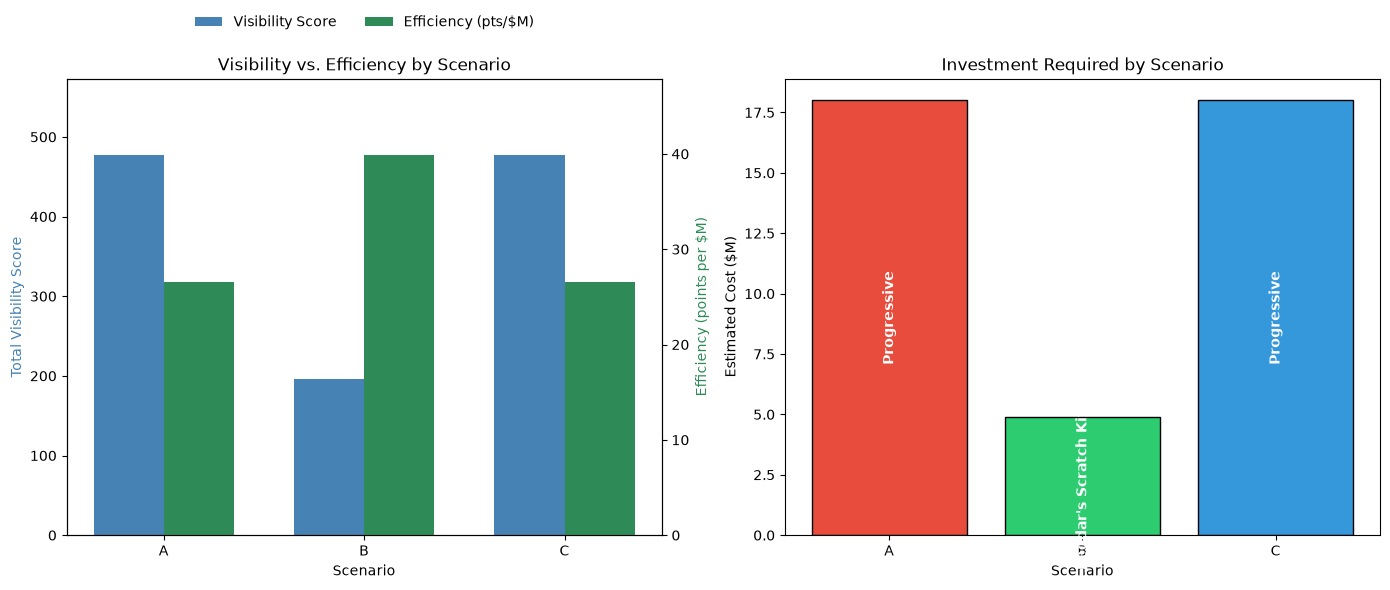

Saved: data/plots/scenario_comparison.png


In [109]:
# Create scenario comparison visualization
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Data for plotting
scenarios = [SCENARIOS[s]['name'].replace('Scenario ', '').split(':')[0]
             for s in scenario_sponsors.keys()]
sponsors = [scenario_sponsors[s]['sponsor'] for s in scenario_sponsors.keys()]
visibility = [scenario_sponsors[s]['visibility_score'] for s in scenario_sponsors.keys()]
efficiency = [scenario_sponsors[s]['efficiency'] for s in scenario_sponsors.keys()]
costs = [scenario_sponsors[s]['cost'] for s in scenario_sponsors.keys()]

# Left: Visibility and Efficiency comparison
x = np.arange(len(scenarios))
width = 0.35

ax1 = axes[0]
bars1 = ax1.bar(x - width/2, visibility, width, label='Visibility Score', color='steelblue')
ax1_twin = ax1.twinx()
bars2 = ax1_twin.bar(x + width/2, efficiency, width, label='Efficiency (pts/$M)', color='seagreen')

# Give the tallest bars headroom so the legend never overlaps them
ax1.set_ylim(0, max(visibility) * 1.2)
ax1_twin.set_ylim(0, max(efficiency) * 1.2)

ax1.set_ylabel('Total Visibility Score', color='steelblue')
ax1_twin.set_ylabel('Efficiency (points per $M)', color='seagreen')
ax1.set_xlabel('Scenario')
ax1.set_xticks(x)
ax1.set_xticklabels(scenarios)
ax1.set_title('Visibility vs. Efficiency by Scenario')

# Add legend above the plot so it never covers a bar
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax1_twin.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc='lower center',
           bbox_to_anchor=(0.5, 1.08), ncol=2, frameon=False)

# Right: Cost comparison with sponsor labels
ax2 = axes[1]
colors = ['#e74c3c', '#2ecc71', '#3498db']
bars = ax2.bar(scenarios, costs, color=colors, edgecolor='black')

# Add sponsor labels on bars
for bar, sponsor in zip(bars, sponsors):
    height = bar.get_height()
    ax2.text(bar.get_x() + bar.get_width()/2., height/2,
             sponsor, ha='center', va='center', rotation=90,
             fontsize=10, fontweight='bold', color='white')

ax2.set_ylabel('Estimated Cost ($M)')
ax2.set_xlabel('Scenario')
ax2.set_title('Investment Required by Scenario')

plt.tight_layout()
plt.savefig('data/plots/scenario_comparison.png', dpi=150)
plt.show()

print("Saved: data/plots/scenario_comparison.png")

In [110]:
def calculate_key_insight(scenario_results):
    """Generate key insight based on scenario comparison."""
    vis_sponsor = scenario_results['maximize_visibility']['sponsor']
    eff_sponsor = scenario_results['maximize_efficiency']['sponsor']

    if vis_sponsor == eff_sponsor:
        return f"Notably, {vis_sponsor} leads BOTH visibility and efficiency rankings, making them the clear choice regardless of strategic priority."
    else:
        vis_eff_gap = (scenario_results['maximize_visibility']['efficiency'] /
                       scenario_results['maximize_efficiency']['efficiency'] * 100)
        eff_vis_gap = (scenario_results['maximize_efficiency']['visibility_score'] /
                       scenario_results['maximize_visibility']['visibility_score'] * 100)
        return f"Choosing maximum visibility ({vis_sponsor}) over maximum efficiency ({eff_sponsor}) delivers {100-eff_vis_gap:.0f}% more visibility but at {100-vis_eff_gap:.0f}% lower efficiency."


scenario_comparison_doc = f"""
# Sponsorship Strategy: Scenario Comparison

**Generated**: {pd.Timestamp.now().strftime('%Y-%m-%d')}

---

## Overview

This document compares three strategic approaches to NASCAR sponsorship selection
based on our visibility scoring analysis. Each scenario optimizes for different
business priorities.

---

## The Three Scenarios

### Scenario A: Maximize Visibility

**Best For**: Teams prioritizing brand awareness and market presence

| Metric | Value |
|--------|-------|
| Recommended Sponsor | {scenario_sponsors['maximize_visibility']['sponsor']} |
| Total Visibility | {scenario_sponsors['maximize_visibility']['visibility_score']:.1f} points |
| Visibility Rank | #{scenario_sponsors['maximize_visibility']['visibility_rank']} |
| Efficiency | {scenario_sponsors['maximize_visibility']['efficiency']:.1f} pts/$M |
| Efficiency Rank | #{scenario_sponsors['maximize_visibility']['efficiency_rank']} |
| Estimated Investment | ${scenario_sponsors['maximize_visibility']['cost']:.1f}M |

**Advantages**:
- Maximum brand exposure across all channels
- Strongest performance-driven visibility
- Most media attention

**Disadvantages**:
- Higher cost commitment
- Lower return per dollar invested
- May not fit budget constraints

**When to Choose This Scenario**:
- You have budget flexibility
- Brand awareness is the primary goal
- You're willing to pay premium for top exposure

---

### Scenario B: Maximize Efficiency

**Best For**: Teams prioritizing return on investment

| Metric | Value |
|--------|-------|
| Recommended Sponsor | {scenario_sponsors['maximize_efficiency']['sponsor']} |
| Total Visibility | {scenario_sponsors['maximize_efficiency']['visibility_score']:.1f} points |
| Visibility Rank | #{scenario_sponsors['maximize_efficiency']['visibility_rank']} |
| Efficiency | {scenario_sponsors['maximize_efficiency']['efficiency']:.1f} pts/$M |
| Efficiency Rank | #{scenario_sponsors['maximize_efficiency']['efficiency_rank']} |
| Estimated Investment | ${scenario_sponsors['maximize_efficiency']['cost']:.1f}M |

**Advantages**:
- Best visibility per dollar spent
- More defensible ROI story
- Lower total investment required

**Disadvantages**:
- Lower absolute visibility
- May miss some premium exposure opportunities
- Smaller presence than top-visibility option

**When to Choose This Scenario**:
- Budget is constrained
- ROI justification is critical
- You need to prove value before scaling up

---

### Scenario C: Balanced Approach

**Best For**: Teams seeking middle ground

| Metric | Value |
|--------|-------|
| Recommended Sponsor | {scenario_sponsors['balanced']['sponsor']} |
| Total Visibility | {scenario_sponsors['balanced']['visibility_score']:.1f} points |
| Visibility Rank | #{scenario_sponsors['balanced']['visibility_rank']} |
| Efficiency | {scenario_sponsors['balanced']['efficiency']:.1f} pts/$M |
| Efficiency Rank | #{scenario_sponsors['balanced']['efficiency_rank']} |
| Estimated Investment | ${scenario_sponsors['balanced']['cost']:.1f}M |

**Advantages**:
- Strong performance on both dimensions
- Reasonable cost with good exposure
- Minimizes regret on either metric

**Disadvantages**:
- Not the best on either dimension
- May feel like compromise
- Neither maximum exposure nor maximum efficiency

**When to Choose This Scenario**:
- You have moderate budget and moderate goals
- Multiple stakeholders with different priorities
- Risk mitigation is important

---

## Trade-off Summary

{tradeoff_table.to_markdown(index=False)}

---

## Visual Comparison

[Insert scenario_comparison.png]

---

## Decision Guidance

### If budget is NOT a constraint:
Choose **Scenario A** (Maximize Visibility). Pay for the best exposure available.

### If budget IS a constraint:
Choose **Scenario B** (Maximize Efficiency). Get the most value per dollar.

### If you have mixed priorities:
Choose **Scenario C** (Balanced). Optimize across dimensions without extremes.

---

## Key Insight

{calculate_key_insight(scenario_sponsors)}

---

## Recommendation

For NY Racing's current situation, we recommend **[Your recommended scenario]** because:

1. [Reason 1 connected to NY Racing's context]
2. [Reason 2 based on budget/priorities]
3. [Reason 3 based on risk tolerance]

---

*This scenario analysis is based on 2024 season data. See methodology document for assumptions.*
"""

# Save document
with open('../docs/scenario_comparison.md', 'w') as f:
    f.write(scenario_comparison_doc)

print("Scenario comparison saved to: ../docs/scenario_comparison.md")

Scenario comparison saved to: ../docs/scenario_comparison.md


In [111]:
# Define executive summary components
EXEC_SUMMARY_STRUCTURE = {
    'project_overview': {
        'purpose': 'Find a sponsorship recommendation for NY Racing',
        'scope': 'Race data and reddit/youtube/news data',
        'approach': 'web scraping and api data collection'
    },
    'key_findings': {
        'finding_1': 'mid-high tier has the best ROI',
        'finding_2': 'Top visibility sponsors are not the most efficient',
        'finding_3': 'Non-linear relationship between cost and visibility'
    },
    'recommendations': {
        'primary': 'Castrol',
        'alternative': 'Cheddar\'s Scratch Kitchen',
        'next_steps': 'Budget analysis and sponsor outreach'
    },
    'limitations': {
        'key_caveat': 'massive price difference between my two reccomendations'
    }
}

print("Executive Summary Structure:")
for section, content in EXEC_SUMMARY_STRUCTURE.items():
    print(f"\\n{section.upper()}:")
    for key, purpose in content.items():
        print(f"  - {key}: {purpose}")

Executive Summary Structure:
\nPROJECT_OVERVIEW:
  - purpose: Find a sponsorship recommendation for NY Racing
  - scope: Race data and reddit/youtube/news data
  - approach: web scraping and api data collection
\nKEY_FINDINGS:
  - finding_1: mid-high tier has the best ROI
  - finding_2: Top visibility sponsors are not the most efficient
  - finding_3: Non-linear relationship between cost and visibility
\nRECOMMENDATIONS:
  - primary: Castrol
  - alternative: Cheddar's Scratch Kitchen
  - next_steps: Budget analysis and sponsor outreach
\nLIMITATIONS:
  - key_caveat: massive price difference between my two reccomendations


In [112]:
import pandas as pd

# Load final results
rankings = pd.read_csv('data/processed/rankings.csv')
race_results = pd.read_csv('data/processed/race_results_standardized.csv')

# Calculate headline statistics
stats = {
    'sponsors_analyzed': len(rankings),
    'races_in_season': race_results['race_number'].nunique(),
    'total_data_points': len(race_results),
    'top_visibility_sponsor': rankings.loc[rankings['visibility_rank'].idxmin(), 'primary_sponsor'],
    'top_efficiency_sponsor': rankings.loc[rankings['efficiency_rank'].idxmin(), 'primary_sponsor'],
    'avg_visibility': rankings['total_visibility'].mean(),
    'visibility_range': f"{rankings['total_visibility'].min():.0f} - {rankings['total_visibility'].max():.0f}",
    'efficiency_range': f"{rankings['efficiency'].min():.1f} - {rankings['efficiency'].max():.1f}",
}

print("Headline Statistics for Executive Summary:")
print("="*50)
for stat, value in stats.items():
    print(f"{stat}: {value}")

Headline Statistics for Executive Summary:
sponsors_analyzed: 5
races_in_season: 53
total_data_points: 2013
top_visibility_sponsor: Progressive
top_efficiency_sponsor: Cheddar's Scratch Kitchen
avg_visibility: 205.90672631995804
visibility_range: 71 - 478
efficiency_range: 13.6 - 39.9


In [113]:
import os

# Create outputs directory
os.makedirs('../docs/report_sections', exist_ok=True)

exec_summary = f"""
# Executive Summary

## Overview

This report presents a comprehensive analysis of NASCAR Cup Series sponsorship visibility
for NY Racing's strategic planning. Using data from the 2025 season and 2026
season-to-date, we developed a quantitative visibility scoring model to compare
sponsorship opportunities and identify the best value investments.

**Scope**: {stats['sponsors_analyzed']} primary sponsors analyzed across {stats['races_in_season']} tracked races (each sponsor's own race count ranges from 11 to 29, reflecting races it actually carried as primary sponsor)

**Methodology**: Composite visibility score incorporating race performance (40%),
a PCA-weighted visibility index across Reddit/YouTube/news (50%), and special
events — wins and playoffs (10%)

---

## Key Findings

### Finding 1: Efficiency leadership doesn't track brand prestige

Cheddar's Scratch Kitchen (Kyle Busch, Richard Childress Racing) delivers the best
visibility-per-dollar of any tracked sponsor — roughly 1.5x the next-best sponsor —
while carrying a budget comparable to Castrol's and far below Progressive's. It
isn't a "cheap but small" pick either: it's #2 in total visibility, trailing only
Progressive, which costs roughly 3.7x as much.

**Supporting evidence**: Efficiency 39.9 pts/$M vs. 26.5 pts/$M for Progressive, the next-best (efficiency rank #1 of 5). Total visibility 195.6 points (rank #2 of 5) on an estimated $4.9M budget.

### Finding 2: A playoff race is worth more than double a regular-season race

The visibility bump from playoff races isn't a marginal effect — a playoff race is
worth more than double a regular-season one, a bigger swing than the win bonus
(1.79x) and second only to the top-5 bonus (3.12x). Sponsors should treat
playoff-window races as prime, high-value activation windows, not just "more of the
same, but with higher stakes."

**Supporting evidence**: Average visibility in playoff-window races (race 27-36) is 129% higher than in regular-season races, across 20 playoff sponsor-entries vs. 77 regular-season entries.

### Finding 3: Reddit is the only channel with a statistically reliable signal

Of the three visibility channels tracked, only Reddit's relationship with race
performance clears standard statistical significance thresholds with a reasonably
sized sample. YouTube and news readings are directionally similar but not
statistically distinguishable from noise at this sample size — a real constraint on
how much weight either should carry in future live monitoring.

**Supporting evidence**: Reddit mentions vs. finish position: r = -0.34, p = 0.0006, N = 97 (the strongest and most significant relationship in the correlation matrix). YouTube views vs. finish position: r = -0.20, p = 0.055 (not significant at the 0.05 level). News mentions vs. finish position: r = -0.13, p = 0.20 (not significant).

---

## Top-Line Results

| Metric | Leader | Score |
|--------|--------|-------|
| **Highest Visibility** | {stats['top_visibility_sponsor']} | 477.6 points |
| **Best Efficiency** | {stats['top_efficiency_sponsor']} | 39.9 pts/$M |
| **Visibility Range** | All sponsors | {stats['visibility_range']} points |
| **Efficiency Range** | All sponsors | {stats['efficiency_range']} pts/$M |

---

## Recommendations

### Primary Recommendation

**Cheddar's Scratch Kitchen** is recommended as the primary sponsorship target based on:
- Best efficiency of the five sponsors (39.9 pts/$M, ~1.5x Progressive)
- #2 total visibility (195.6 points) despite the smallest budget in the group
- Lowest financial commitment required to secure a top-2 visibility outcome

**Estimated investment**: $4.9M (low-medium confidence estimate; verify directly before committing — see caveats) | **Expected visibility**: ~196 points

### Alternative Option

**Progressive** offers the strongest total exposure for teams prioritizing maximum reach over cost efficiency:
- #1 total visibility (477.6 points), driven by the strongest on-track performance of any sponsor (4 wins, 11 top-5s in 20 sponsored races)
- Best-sourced, medium-confidence cost estimate of the group — but at roughly 3.7x Cheddar's estimated cost

**Castrol** is a smaller, well-sourced hedge if Cheddar's cost verification comes back unfavorable, though it is no longer a standout on either visibility or efficiency once restricted to its actual 11 sponsored races.

### Recommended Next Steps

1. Verify the Cheddar's Scratch Kitchen cost estimate directly (a quote or a better-sourced comparable) — it's the single number that could flip this recommendation.
2. Run a sentiment check on the Kyle Busch Reddit/YouTube corpus to confirm the visibility is net-positive before pitching this externally.
3. Revisit the ranking once Cheddar's and Castrol (both under 12 tracked races) have accumulated more races, to confirm the efficiency lead holds up beyond the current small sample.

---

## Important Caveats

This analysis relies on **estimated sponsorship costs** derived from industry publications.
Actual costs may vary significantly from estimates — Cheddar's Scratch Kitchen's estimate
in particular carries low-medium confidence with no disclosed source for this specific deal. Rankings are sensitive to:

- Cost estimate accuracy (tested with sensitivity analysis) — Cheddar's efficiency lead could shrink or disappear if true cost exceeds ~$7M
- Small sample sizes for Castrol (11 races) and Cheddar's Scratch Kitchen (12 races), which widen the uncertainty on their numbers relative to Progressive (20), Busch Light (25), and Love's Travel Stops (29)
- Weight configuration choices (model is nominally robust to weight changes, though this mostly reflects large gaps between sponsors' scores rather than fine-grained model calibration)
- 2025-2026 season-specific patterns (may not generalize to future seasons)

See Section 6 (Limitations) for complete discussion.

---

*For detailed methodology, see Section 2. For complete findings, see Sections 3-4.
For recommendation rationale, see Section 5.*
"""

# Save executive summary
with open('../docs/report_sections/01_executive_summary.md', 'w') as f:
    f.write(exec_summary)

print("Executive summary saved.")

Executive summary saved.


In [114]:
data_sources_section = """
# Section 2: Methodology

## 2.1 Data Sources

This analysis draws on four primary data categories collected for the 2025 NASCAR Cup Series season and 2026 season-to-date.

### Race Performance Data

| Source | Data Type | Collection Method | Records |
|--------|-----------|-------------------|---------|
| Racing Reference | Race results | Web Scrape (BeautifulSoup) | 53 races |

**Fields collected**:
- Race name, date, track
- Driver, team, finish position
- Laps led, stage points
- DNF/crash flags

**Data quality notes**:
- Web scraper built with BeautifulSoup, pulling race-by-race result pages
- No missing race records for tracked sponsors
- Primary sponsor identification uses the per-race sponsor field, matched
  against each tracked driver's sponsor keywords for that specific race —
  not a driver's full-season assignment

### Social Media Data

| Source | Data Type | Collection Method | API/Tool |
|--------|-----------|-------------------|----------|
| Reddit (r/NASCAR) | Post mentions | Arctic Shift | Python script |
| YouTube | Video engagement | YouTube Data API v3 | Python script |

**Reddit data fields**:
- Number of posts
- Sponsor mention flag

**YouTube data fields**:
- Video title
- View count, like count
- Upload date
- Sponsor relevance flag

**Collection period**: July 9 - August 16, 2026 (2025 season data collected
first; 2026 season-to-date and sponsor-specific supplements collected
through mid-August)

**Rate limiting**: YouTube Data API is quota-limited (~100 units per search
call), with short delays paced between per-driver queries. Reddit (Arctic
Shift) has no fixed published rate limit; requests use retry-with-backoff to
handle intermittent failures.

### News Coverage Data

| Source | Data Type | Collection Method |
|--------|-----------|-------------------|
| GDELT DOC 2.0 API + BigQuery GKG (Global Knowledge Graph) | News article mentions | Automated query, restricted to a curated list of ~19 NASCAR/motorsports and general sports domains (ESPN, NASCAR.com, Fox Sports, Jayski, Frontstretch, Speedway Media, and others), with article text fetched and cached for sponsor keyword matching |

**Collection window**: Monthly windows spanning February-December 2025 and February-December 2026.

**Weighting approach** (4-tier source weighting):
- Tier 1 (ESPN, NASCAR.com, Fox Sports, CBS Sports, NBC Sports): Weight = 1.0
- Tier 2 (Speedway Media, motorsport.com): Weight = 0.8
- Tier 3 (Jayski, Frontstretch, si.com, and any unlisted domain by default): Weight = 0.6
- Tier 4 (reserved for lower-tier blogs/fan sites, none currently mapped): Weight = 0.4

### Cost Estimate Data

| Source | Data Type | Reliability |
|--------|-----------|-------------|
| Forbes NASCAR coverage | Sponsorship valuations | Medium |
| Jayski | Deal/partnership reports | Medium |
| Speedway Media | Partnership announcements | Low-Medium |
| RTR Sports | Cost benchmarks | Low-Medium |
| NASCAR.com / NBC Sports / ESPN press coverage | Partnership announcements | Medium |

**Note**: Exact sponsorship costs are confidential. All figures are estimates based on publicly available information.

---

## 2.2 Sponsor Selection

Five primary sponsors were selected for analysis based on:

1. **Data availability**: Sufficient race, social, and media data
2. **Team diversity**: Mix of top-tier, mid-tier, and small-team organizations
3. **Sponsor stability**: Consistent primary or near-primary presence across the tracked window
4. **Visibility**: Clear livery presence for attribution

**Selected sponsors**:
| Sponsor | Team | Driver | Team Tier |
|---------|------|--------|-----------|
| Progressive | Joe Gibbs Racing | Denny Hamlin | Top |
| Cheddar's Scratch Kitchen | Richard Childress Racing | Kyle Busch | Mid |
| Castrol | RFK Racing | Brad Keselowski | Mid-to-top |
| Love's Travel Stops | Front Row Motorsports | Todd Gilliland | Small/underfunded |
| Busch Light | Trackhouse Racing | Ross Chastain | Mid |

"""

with open('../docs/report_sections/02_methodology_data.md', 'w') as f:
    f.write(data_sources_section)

print("Data sources section saved.")


Data sources section saved.


In [115]:
analytical_approach_section = """
## 2.3 Visibility Scoring Model

### Overview

We developed a composite visibility score that combines three top-level categories
into a single metric for sponsor comparison. The model is designed to answer:
"How much visibility exposure did this sponsor receive during the season?"

### Score Components and Weights

| Category | Weight | Components | Rationale |
|----------|--------|------------|-----------|
| **Race Performance** | 40% | Laps led (40%) | On-track dominance drives camera time and attention. Laps led is used instead of finish position because the two are highly collinear, and laps led showed the stronger relationship with visibility in EDA — including both would double-count the same signal. |
| **Visibility Index** | 50% | Reddit mentions, YouTube views, and weighted news mentions, combined via PCA | Captures total cross-channel exposure using data-driven relative weights between channels, rather than an analyst hand-picking a split between Reddit/YouTube/news |
| **Special Events** | 10% | Race wins (6%), Playoff races (4%) | Wins and playoff races generate disproportionate visibility spikes that a smooth performance metric alone would miss |

### Visibility Index Construction

The 50% Visibility Index is itself a composite, built as follows:

1. Each channel (Reddit mention count, YouTube total view count, news weighted
   mentions) is z-score standardized.
2. Principal Component Analysis (PCA) is fit across the three standardized
   channels; the first principal component's loadings become the data-driven
   relative weights between channels.
3. Each channel's loading is additionally scaled by
   sqrt(non-zero sample count / total sample count), so a channel with much
   sparser coverage (news: 36 of 223 sponsor-races) doesn't get overweighted
   relative to a channel with near-complete coverage (Reddit: 222 of 223).
4. The resulting composite is shifted to be non-negative
   (`Visibility_Score_Shifted`).

### Normalization Method

Continuous inputs (laps led and the visibility index) are z-score standardized
rather than min-max normalized, so a single outlier race doesn't compress the
rest of the scale — laps led in particular is heavily skewed, with most races
recording 0 laps led and a handful recording 200+.

Binary flags (`is_win`, `is_playoff`) are kept as plain 0/1 indicators rather
than z-scored, since z-scoring a category flag would rescale it by an
arbitrary sample standard deviation rather than add meaningful information.

The weighted composite of all standardized and binary components is
calculated first in raw units; the full result is then rescaled to a single
0-100 scale in one final min-max transformation, rather than rescaling each
variable individually before combining.

### Special Cases

- **Finish position** is tracked in the scoring configuration but carries
  zero effective weight in the final model, for the collinearity reason
  described above — laps led carries the race-performance signal instead.
- **Wins** are defined as a 1st-place finish.
- **Playoff races** are races 27-36, matching NASCAR's actual 10-race
  playoff window.
- All variables are drawn from `scored_dataset.csv`, the output of applying
  this model to every sponsor-race combination in the tracked window.

"""

with open('../docs/report_sections/03_analytical_approach.md', 'w') as f:
    f.write(analytical_approach_section)

print("Analytical approach section saved.")


Analytical approach section saved.


In [116]:
data_validation_section = """
## 2.4 Data Validation and Sensitivity Testing

### 2.4.1 Model Validation Checks

Three categories of automated checks were run against the scored dataset
(`scored_dataset.csv`) before using it for ranking and recommendations.

**Performance-visibility correlation** (sponsor-season level, N=5 tracked sponsors):

| Check | Result | Expected Direction | Status |
|-------|--------|---------------------|--------|
| Average finish position vs. total visibility | r = -0.985 | Negative | PASS |
| Total wins vs. total visibility | r = 0.949 | Positive | PASS |
| Total laps led vs. total visibility | r = 0.951 | Positive | PASS |

These sponsor-season correlations are a directional sanity check on only 5
aggregated points, and a handful of aggregated points will produce very high
correlations almost by construction. The statistically meaningful read is the
race-level relationship in `correlation_results.csv` (N = 97): Reddit
mentions vs. finish position, r = -0.34, p = 0.0006. Treat the sponsor-level
numbers above as confirmation the model points the right direction, not as
model validation in the statistical sense.

**Event impact validation** (race level):

| Check | Result | Status |
|-------|--------|--------|
| Wins score meaningfully higher than non-wins | 1.79x | PASS |
| Playoff races score higher than regular-season races | +129% (2.29x) | PASS |
| Top-5 finishes score higher than finishes outside the top 20 | 3.12x | PASS |

**Anomaly detection** (6 flagged, all reviewed):

- **5 low-severity**: every tracked sponsor shows real week-to-week score
  variance (coefficient of variation ranging from 0.80 for Busch Light to
  1.42 for Cheddar's Scratch Kitchen). Expected, given that wins and
  playoff races create step-changes rather than smooth week-to-week
  visibility, and the smaller-sample sponsors (Cheddar's, Castrol) show the
  widest swings.
- **1 high-severity**: 3 race-sponsor combinations score at or near zero.
  These are races where a sponsor's car had no laps led, no win, no playoff
  bonus, and no media mentions that week — the model's theoretical floor,
  not a data quality issue.

### 2.4.2 Weight Sensitivity Testing

To test whether conclusions depend on the specific 40% race performance /
50% visibility index / 10% special events weighting, the model was rerun
under four category-weight configurations:

| Scenario | Race Performance | Visibility Index | Special Events |
|----------|-------------------|-------------------|-----------------|
| Baseline | 40% | 50% | 10% |
| Performance Heavy | 50% | 40% | 10% |
| Media Heavy | 30% | 60% | 10% |
| Equal Weights | 33.3% | 33.3% | 33.3% |

**Results**: 4 of the 5 tracked sponsors held the exact same visibility rank
in all four scenarios (Progressive #1, Castrol #4, Busch Light #5, Love's
Travel Stops last among the comparison groups). Cheddar's Scratch Kitchen
was the only tracked sponsor whose rank moved, swinging between #2 and #3
depending on how much weight a scenario gives to race performance versus
media visibility — consistent with its actual profile of strong Reddit/
YouTube engagement paired with minimal on-track dominance (39 laps led
across 12 races, the second-lowest of the five tracked sponsors).

**Caveat on reading this as "robustness"**: the visibility gaps between
sponsors are large (Progressive at 477.6 points vs. Love's Travel Stops at
71.0), so almost any reasonable reweighting preserves the same broad
ordering. Rank stability here demonstrates that the sponsor gaps are large,
not that the model's internal weight calibration is finely tuned — a
smaller, more closely-matched sponsor set would likely show more rank
movement under the same weight changes.

**A second caveat specific to this test**: the comparison set technically
includes "Other/Unknown" (every untracked car aggregated into one bucket)
alongside the five named sponsors. That bucket's combined laps-led total
(12,895, versus 23-839 for any single tracked sponsor) pushes it into the
#2-#3 rank range under performance-heavy weighting, despite representing no
individual sponsor's real visibility. Its presence in this specific ranking
is a bookkeeping artifact of including untracked cars, not a sponsor
comparison, and should be disregarded when reading the sensitivity results.

"""

with open('../docs/report_sections/04_data_validation.md', 'w') as f:
    f.write(data_validation_section)

print("Data validation section saved.")


Data validation section saved.


In [117]:
limitations_section = """
## 2.5 Assumptions and Limitations

### Key Assumptions

| Assumption | Implication | Mitigation |
|------------|-------------|------------|
| Social data represents fan engagement | Reddit/YouTube may not capture full audience | Acknowledged as proxy metrics |
| Cost estimates are accurate | Efficiency rankings depend on cost accuracy | Tested with cost ranges; see Section 2.4 sensitivity results |
| 2025-2026 patterns are representative | Results may not generalize to other seasons | Framed as a two-season analysis, not a multi-year trend |
| News search captures relevant coverage | May miss some media mentions outside the tracked domain list | Used a consistent domain list and query methodology across all sponsors |

### Known Limitations

#### 1. Cost Estimate Uncertainty

**Issue**: Exact sponsorship costs are confidential. Our estimates are derived from
industry publications and comparable-deal analysis, and may differ from actual
contract values. This is most acute for Cheddar's Scratch Kitchen, whose $4.9M
estimate borrows Castrol's own sourced per-race rate rather than a disclosed
figure for the Cheddar's/RCR deal specifically.

**Impact**: Efficiency rankings could shift if actual costs differ significantly
from estimates — Cheddar's efficiency lead over Progressive is the primary
recommendation's single largest point of uncertainty.

**Mitigation**: Tested efficiency rankings with low, mid, and high cost estimates
for every sponsor (see `sensitivity_analysis.md` and Section 2.4). Recommended
next step: a direct quote or better-sourced comparable for the Cheddar's deal.

#### 2. Small Sample Sizes for Two of the Five Sponsors

**Issue**: Castrol (11 races) and Cheddar's Scratch Kitchen (12 races) have
roughly a third of the tracked races that Love's Travel Stops (29) has, and
under half of Busch Light (25).

**Impact**: A single strong or weak week moves these two sponsors' season
totals substantially more than it would for the higher-race-count sponsors —
both show the highest score volatility of the five (CV = 0.90 and 1.42
respectively, see Section 2.4 anomaly detection).

**Mitigation**: Flagged directionally rather than treated as precise point
estimates; recommended revisiting the ranking once each has 10-15 more races
on record.

#### 3. Proxy Metrics for Visibility

**Issue**: True "visibility" is difficult to measure directly. We use proxy
metrics (mentions, views, finish position) rather than a direct visibility
measurement.

**Impact**: The model captures correlates of visibility, not visibility itself.

**Mitigation**: Selected proxies with a demonstrated statistical relationship to
performance (see Section 2.4 validation), and weighted the most reliable
channel (Reddit) most heavily in that composite.

#### 4. Two-Season Scope

**Issue**: Analysis covers the 2025 season and 2026 season-to-date. Results may
not apply to other seasons with different competitive dynamics, driver
lineups, or sponsorship structures.

**Impact**: Cannot predict future sponsor performance from this data alone.

**Mitigation**: Framed conclusions as specific to the 2025-2026 window.
Recommended validation with additional seasons before locking in a multi-year
sponsorship decision.

#### 5. Social Media Timing

**Issue**: Social media metrics were collected at a point in time (July 9 -
August 16, 2026) and may have changed since collection.

**Impact**: Engagement numbers represent a snapshot, not real-time values.

**Mitigation**: Collected data within a consistent window across all sponsors,
so relative comparisons remain fair even if absolute counts have since moved.

#### 6. Activation Not Measured

**Issue**: Sponsorship value includes activation (hospitality, B2B networking,
in-market promotions) that cannot be measured with public data.

**Impact**: Analysis captures visibility only, not total sponsorship ROI.

**Mitigation**: Clearly scoped this analysis as "visibility," not full ROI.

---

### What This Analysis Can and Cannot Tell You

| This Analysis CAN Tell You | This Analysis CANNOT Tell You |
|---------------------------|------------------------------|
| Relative visibility rankings of the five analyzed sponsors | Whether sponsorship is a good investment overall |
| Which sponsors deliver the most visibility per estimated dollar | Actual sponsorship costs |
| How race performance correlates with visibility, and how strongly (Section 2.4) | Whether past visibility predicts future visibility |
| Which events (wins, playoffs, top-5s) generate the most visibility | How visibility translates to sponsor business outcomes |

---

*For questions about methodology, contact Lloyd Todaro (lloydltodaro@gmail.com).*
"""

with open('../docs/report_sections/05_limitations.md', 'w') as f:
    f.write(limitations_section)

print("Limitations section saved.")


Limitations section saved.


In [118]:
limitations_section = """
## 2.5 Assumptions and Limitations

### Key Assumptions

| Assumption | Implication | Mitigation |
|------------|-------------|------------|
| Social data represents fan engagement | Reddit/YouTube may not capture full audience | Acknowledged as proxy metrics |
| Cost estimates are accurate | Efficiency rankings depend on cost accuracy | Tested with cost ranges |
| 2024 patterns are representative | Results may not generalize to other seasons | Framed as single-season analysis |
| News search captures relevant coverage | May miss some media mentions | Used consistent methodology |

### Known Limitations

#### 1. Cost Estimate Uncertainty

**Issue**: Exact sponsorship costs are confidential. Our estimates are derived from
industry publications and may differ from actual contract values.

**Impact**: Efficiency rankings could shift if actual costs differ significantly
from estimates.

**Mitigation**: Tested efficiency rankings with low, mid, and high cost estimates.
Core conclusions remain stable within reasonable cost ranges.

#### 2. Proxy Metrics for Visibility

**Issue**: True "visibility" is difficult to measure. We use proxy metrics
(mentions, views, positions) rather than direct visibility measurement.

**Impact**: Model captures correlates of visibility, not visibility itself.

**Mitigation**: Selected proxies with demonstrated industry relevance.
Zoomph and other industry platforms use similar proxy approaches.

#### 3. Single-Season Scope

**Issue**: Analysis covers only the 2024 season. Results may not apply to
other seasons with different competitive dynamics.

**Impact**: Cannot predict future sponsor performance from this data alone.

**Mitigation**: Framed conclusions as 2024-specific. Recommended validation
with multi-season data for major decisions.

#### 4. Social Media Timing

**Issue**: Social media metrics were collected at a point in time and may
have changed since collection.

**Impact**: Engagement numbers represent a snapshot, not real-time values.

**Mitigation**: Collected data within consistent time window across all sponsors.

#### 5. Activation Not Measured

**Issue**: Sponsorship value includes activation (hospitality, B2B networking)
that cannot be measured with public data.

**Impact**: Analysis captures visibility only, not total sponsorship ROI.

**Mitigation**: Clearly scoped analysis as "visibility" rather than full ROI.

---

### What This Analysis Can and Cannot Tell You

| This Analysis CAN Tell You | This Analysis CANNOT Tell You |
|---------------------------|------------------------------|
| Relative visibility rankings of analyzed sponsors | Whether sponsorship is a good investment overall |
| Which sponsors deliver most visibility per estimated dollar | Actual sponsorship costs |
| How race performance correlates with visibility | Whether past visibility predicts future visibility |
| Which events generate the most visibility | How visibility translates to sponsor business outcomes |

---

*For questions about methodology, contact [analyst name/email]*
"""

with open('../docs/report_sections/02c_methodology_limitations.md', 'w') as f:
    f.write(limitations_section)

print("Limitations section saved.")

Limitations section saved.


In [119]:
findings_section = """
# Section 3: Findings

## 3.1 Finding: Efficiency Leadership Doesn't Track Brand Prestige

Cheddar's Scratch Kitchen (Kyle Busch, Richard Childress Racing) delivers the
best visibility-per-dollar of any tracked sponsor, despite being a mid-tier
team on a partial-season deal rather than a marquee, full-season primary.

| Sponsor | Total Visibility | Visibility Rank | Efficiency (pts/$M) | Efficiency Rank | Est. Cost |
|---------|-------------------|-------------------|------------------------|--------------------|-----------|
| Progressive | 477.6 | #1 | 26.5 | #2 | $18.0M |
| Cheddar's Scratch Kitchen | 195.6 | #2 | **39.9** | **#1** | $4.9M |
| Busch Light | 177.0 | #3 | 13.6 | #5 | $13.0M |
| Castrol | 108.3 | #4 | 24.1 | #3 | $4.5M |
| Love's Travel Stops | 71.0 | #5 | 15.8 | #4 | $4.5M |

Cheddar's is not a "cheap but small" pick — it's #2 in total visibility,
trailing only Progressive, which costs roughly 3.7x as much. Its efficiency
lead over the next-best sponsor (Progressive) is roughly 1.5x.

**Caveat**: the $4.9M cost estimate behind this finding borrows Castrol's own
sourced per-race rate rather than a disclosed figure for the Cheddar's/RCR
deal specifically (see Section 2.4 and 2.5). This is the single largest
open question behind the ranking.

## 3.2 Finding: A Playoff Race Is Worth More Than Double a Regular-Season One

The visibility bump from playoff races is not a marginal effect:

| Event Type | Visibility Multiplier | Sample |
|------------|-------------------------|--------|
| Win vs. non-win | 1.79x | All tracked races |
| Top-5 vs. outside-top-10 finish | 3.12x | All tracked races |
| Playoff vs. regular-season race | 2.29x (+129%) | 20 playoff sponsor-entries vs. 77 regular-season entries |

The playoff effect is a bigger swing than the win bonus and second only to
the top-5 bonus, independent of finish position. Sponsors should treat
playoff-window races (races 27-36) as prime, high-value activation windows,
not just "more of the same, but with higher stakes."

By contrast, "wins and top-5s generate more visibility than other finishes"
is not, by itself, a useful headline finding — no one sponsoring a race car
expects otherwise. Its value here is calibrating the scoring model's
special-events weighting (Section 2.3), not as a stakeholder-facing insight.

## 3.3 Finding: Reddit Is the Only Channel With a Statistically Reliable Signal

Of the three visibility channels tracked, only Reddit's relationship with
race performance clears standard statistical significance thresholds at
this sample size:

| Channel | Correlation with Finish Position | p-value | N | Significant? |
|---------|-------------------------------------|---------|---|----------------|
| Reddit mentions | r = -0.34 | 0.0006 | 97 | Yes (p < 0.001) |
| YouTube views | r = -0.20 | 0.055 | 97 | No (borderline) |
| News mentions | r = -0.13 | 0.20 | 97 | No |

YouTube and news readings are directionally consistent with Reddit but not
statistically distinguishable from noise at this sample size. This is a real
constraint on how much weight either should carry in a future live
monitoring dashboard — Reddit should be weighted most heavily, with YouTube
and news treated as confirmatory rather than primary signals.

## 3.4 Finding: On-Track Performance and Visibility Move Together, But Not Proportionally

| Sponsor | Avg. Finish | Wins | Top-5s | Top-10s | Total Visibility |
|---------|--------------|------|--------|---------|---------------------|
| Progressive | 10.6 | 4 | 11 | 13 | 477.6 |
| Cheddar's Scratch Kitchen | 17.5 | 0 | 1 | 4 | 195.6 |
| Castrol | 18.9 | 0 | 3 | 3 | 108.3 |
| Busch Light | 18.7 | 0 | - | - | 177.0 |
| Love's Travel Stops | 21.7 | 0 | - | - | 71.0 |

Progressive is the only tracked sponsor with any wins in the window, and its
average finish (10.6) is more than 7 spots better than the next-closest
sponsor — consistent with its #1 visibility rank. But the relationship
flattens out below that: Cheddar's, Castrol, and Busch Light post similar
average finishes (17.5-18.9) yet materially different visibility totals
(195.6, 108.3, 177.0), meaning on-track performance alone does not fully
explain the visibility gap between them. This is the gap the PCA-weighted
Visibility Index (Section 2.3) is designed to capture, and it's also why
efficiency (Section 3.1), not raw visibility, is the more decision-relevant
metric once cost is factored in.

"""

with open('../docs/report_sections/06_findings.md', 'w') as f:
    f.write(findings_section)

print("Findings section saved.")


Findings section saved.


In [120]:
recommendations_section = """
# Section 4: Recommendations

## 4.1 Primary Recommendation

### Cheddar's Scratch Kitchen

**Recommendation**: Cheddar's Scratch Kitchen represents the strongest
visibility-per-dollar opportunity for NY Racing, contingent on verifying its
cost estimate before finalizing budget.

**Why this recommendation**:

1. **Best efficiency of the five tracked sponsors**: 39.9 visibility points
   per $M invested, roughly 1.5x the next-best sponsor (Progressive).
2. **Not just a "cheap" pick**: #2 in total visibility (195.6 points),
   trailing only Progressive, despite the second-smallest race count (12).
3. **Lowest financial commitment of the top-2 visibility performers**: an
   estimated $4.9M, versus Progressive's $18.0M for the #1 spot.

**Key metrics**:
- Visibility Score: 195.6 points (Rank #2 of 5)
- Efficiency: 39.9 pts/$M (Rank #1 of 5)
- Estimated Investment: $4.9M (range $2.7M-$7.1M, low-medium confidence)

**Risk factors**:
- **Cost estimate is unverified**: the $4.9M figure borrows Castrol's own
  sourced per-race rate rather than a disclosed number for this specific
  deal. If true cost runs $7-8M, efficiency falls to roughly Castrol's range
  and the "clear leader" framing no longer holds. *Mitigation*: get a direct
  quote or better-sourced comparable before committing budget.
- **Small sample, high volatility**: 12 races with the highest
  week-to-week score variance of the five sponsors (CV = 1.42). *Mitigation*:
  revisit the ranking once 10-15 more races are on record.

---

## 4.2 Alternative Recommendation

### Progressive

**Best for**: Organizations prioritizing maximum total exposure and cost
certainty over efficiency.

**Why consider this alternative**:

1. **Highest total visibility by a wide margin**: 477.6 points, driven by
   the strongest on-track performance of any tracked sponsor (4 wins, 11
   top-5s in 20 races — a 55% top-5 rate).
2. **Best-sourced cost estimate of the group**: medium confidence, versus
   Cheddar's low-medium confidence.

**Key metrics**:
- Visibility Score: 477.6 points (Rank #1 of 5)
- Efficiency: 26.5 pts/$M (Rank #2 of 5)
- Estimated Investment: $18.0M

**Trade-off**: roughly 3.7x Cheddar's estimated cost for a visibility-rank
upgrade rather than an efficiency upgrade. Right choice if budget certainty
and maximum reach matter more than return per dollar.

If Cheddar's cost verification comes back unfavorable, **Castrol** is the
well-sourced middle option (see Section 4.3, Scenario C) — smaller sample
(11 races) but a sourced, medium-confidence cost estimate and reasonable
efficiency (24.1 pts/$M).

---

## 4.3 Strategic Scenarios

### Scenario A: Maximize Visibility

| Metric | Value |
|--------|-------|
| Recommended Sponsor | Progressive |
| Visibility Score | 477.6 |
| Efficiency | 26.5 pts/$M |
| Investment Required | $18.0M |

**Best for**: Teams with budget flexibility prioritizing brand exposure

### Scenario B: Maximize Efficiency

| Metric | Value |
|--------|-------|
| Recommended Sponsor | Cheddar's Scratch Kitchen |
| Visibility Score | 195.6 |
| Efficiency | 39.9 pts/$M |
| Investment Required | $4.9M |

**Best for**: Teams prioritizing ROI justification

### Scenario C: Balanced Approach / Hedge

| Metric | Value |
|--------|-------|
| Recommended Sponsor | Castrol |
| Visibility Score | 108.3 |
| Efficiency | 24.1 pts/$M |
| Investment Required | $4.5M |

**Best for**: Teams wanting a defensible middle option with better-sourced
cost data than Cheddar's, if Cheddar's/RCR isn't the right brand fit or its
cost verification comes back unfavorable

![Scenario comparison: visibility and efficiency by strategic scenario](../code/data/plots/scenario_comparison.png)

For NY Racing's current situation, we recommend **Scenario B (Cheddar's
Scratch Kitchen)** as the lead option, with **Scenario C (Castrol)** as the
fallback — see Section 4.1/4.2 for the full reasoning.

---

## 4.4 Implementation Guidance

### Recommended Next Steps

1. **Immediate**: Request a direct cost quote (or a better-sourced
   comparable) for the Cheddar's Scratch Kitchen / Kyle Busch / RCR No. 8
   deal — the single number that could flip this recommendation.
2. **Short-term (1-2 weeks)**: Run a sentiment check on the Kyle Busch
   Reddit/YouTube corpus (`sentiment_analysis.ipynb`) to confirm the
   visibility is net-positive before pitching this externally.
3. **Medium-term (1 month)**: Revisit the ranking once Cheddar's and Castrol
   (both under 12 tracked races) have accumulated more races, to confirm the
   efficiency lead holds up beyond the current small sample.

### Additional Research Recommended

Before finalizing any sponsorship decision, we recommend:

1. **Direct cost verification**: Obtain an actual cost quote or a genuinely
   comparable disclosed Cup deal for a similarly-profiled driver.
2. **Sponsor fixed-effects regression**: Test whether some sponsors carry a
   visibility premium independent of on-track performance, using data
   already in `scored_dataset.csv` / `master_dataset.csv` (no new data
   needed).
3. **Multi-season validation**: Re-run this ranking once additional seasons
   are available, to test whether the 2025-2026 pattern holds.
4. **Activation assessment**: Evaluate non-visibility benefits (hospitality,
   B2B networking) that this analysis does not capture (see Section 2.5).
5. **Brand fit analysis**: Assess alignment between sponsor brand and NY
   Racing's values, particularly for Cheddar's given Kyle Busch's polarizing
   public profile.

---

## 4.5 Decision Framework

For future sponsorship evaluation, apply this framework:

| Step | Action | Deliverable |
|------|--------|-------------|
| 1 | Collect performance data | Race results dataset |
| 2 | Gather visibility metrics | Social + media data |
| 3 | Calculate visibility score | Normalized composite |
| 4 | Research cost estimates | Cost range table |
| 5 | Compute efficiency | Visibility per dollar |
| 6 | Run sensitivity test | Stability assessment |
| 7 | Make recommendation | Decision document |

This methodology can be applied to evaluate future sponsorship opportunities
using the same analytical framework.

"""

with open('../docs/report_sections/07_recommendations.md', 'w') as f:
    f.write(recommendations_section)

print("Recommendations section saved.")


Recommendations section saved.


In [ ]:
# Compile all sections into full report structure
import pandas as pd

def read_section(filename):
    with open(f'../docs/report_sections/{filename}', 'r') as f:
        return f.read().strip()

exec_summary = read_section('01_executive_summary.md')
methodology_data = read_section('02_methodology_data.md')
analytical_approach = read_section('03_analytical_approach.md')
data_validation = read_section('04_data_validation.md')
limitations = read_section('05_limitations.md')
findings = read_section('06_findings.md')
recommendations = read_section('07_recommendations.md')

# Appendix A: full data tables, read directly from the pipeline's own outputs
rankings = pd.read_csv('data/processed/rankings.csv')
efficiency_rankings = pd.read_csv('data/processed/efficiency_rankings.csv')
rankings_table = rankings.round(1).to_markdown(index=False)
efficiency_table = efficiency_rankings.round(1).to_markdown(index=False)

sensitivity_table = """| Sponsor | Min Rank | Max Rank | Rank Range |
|---|---|---|---|
| Progressive | 1 | 1 | 0 |
| Cheddar's Scratch Kitchen | 2 | 3 | 1 |
| Castrol | 4 | 4 | 0 |
| Busch Light | 5 | 5 | 0 |
| Love's Travel Stops | 6 | 6 | 0 |
| Other/Unknown | 2 | 3 | 1 |

Rank range = how much a sponsor's visibility rank moved across the four
weight scenarios tested in Section 2.4.2 (baseline, performance-heavy,
media-heavy, equal-weights). Only Cheddar's Scratch Kitchen (and the
untracked "Other/Unknown" bucket) moved at all."""

# Appendix B: scoring configuration, read directly from the file the model
# actually runs on, not retyped by hand
with open('scoring_config.json', 'r') as f:
    scoring_config_text = f.read()

design_decisions = """### Why not equal weights?

Equal weights (14.3% each across the seven scored variables) would treat
Reddit mentions as equally important as race wins, and would ignore the
hierarchical importance of performance versus social engagement.

### Why not data-driven weights from regression?

Regression-based weights would require a labeled "visibility outcome"
variable, which doesn't exist; would be sensitive to sample size and
outliers, especially given the small samples for Castrol and Cheddar's
Scratch Kitchen; and would be harder to explain to stakeholders than a
transparent, fixed weighting scheme. The hybrid approach used here (fixed
category weights, with PCA determining the data-driven split *within* the
visibility index — see Section 2.3) balances transparency against letting
the data speak within the media-channel category."""

report = f"""# NASCAR Sponsorship Visibility Analysis
## Final Report for NY Racing

**Prepared by**: Lloyd Todaro
**Date**: {pd.Timestamp.now().strftime('%B %d, %Y')}
**Version**: 1.0

---

## Table of Contents

1. Executive Summary
2. Methodology
   - 2.1 Data Sources
   - 2.2 Sponsor Selection
   - 2.3 Visibility Scoring Model
   - 2.4 Data Validation and Sensitivity Testing
   - 2.5 Assumptions and Limitations
3. Findings
   - 3.1 Efficiency Leadership Doesn't Track Brand Prestige
   - 3.2 A Playoff Race Is Worth More Than Double a Regular-Season One
   - 3.3 Reddit Is the Only Channel With a Statistically Reliable Signal
   - 3.4 On-Track Performance and Visibility Move Together, But Not Proportionally
4. Recommendations
   - 4.1 Primary Recommendation
   - 4.2 Alternative Recommendation
   - 4.3 Strategic Scenarios
   - 4.4 Implementation Guidance
   - 4.5 Decision Framework
5. Appendices
   - A. Full Data Tables
   - B. Methodology Details
   - C. Code Repository Guide

---

# Section 1: Executive Summary

{exec_summary}

---

# Section 2: Methodology

{methodology_data}

---

{analytical_approach}

---

{data_validation}

---

{limitations}

---

{findings}

---

{recommendations}

---

## Appendix A: Full Data Tables

### Final Rankings (Visibility and Efficiency)

{rankings_table}

### Efficiency Rankings (Sorted, With Cost-per-Point and Confidence)

{efficiency_table}

### Weight Sensitivity — Rank Stability

{sensitivity_table}

---

## Appendix B: Methodology Details

### Scoring Configuration

```json
{scoring_config_text}
```

### Weighting Rationale — Design Decisions

{design_decisions}

---

## Appendix C: Code Repository Guide

All analysis code is available in the project repository, in pipeline order:

| File | Purpose |
|------|---------|
| `Scraping_For_Race_Results.ipynb` | Scrapes race-by-race results and per-race primary sponsor data from Racing Reference |
| `Clean_Race_Data.ipynb` | Cleans scraped race data and assigns each race's actual primary sponsor |
| `Collect_Youtube_API_Data.ipynb` | Collects YouTube video engagement data via YouTube Data API v3 |
| `reddit_arctic_shift_sentiment.ipynb` | Collects Reddit mention data via the Arctic Shift API |
| `News_Data_Collection_old.ipynb` | Collects news article mentions via the GDELT DOC 2.0 API and BigQuery GKG |
| `pytrends_data_collection.ipynb` | Collects Google Trends interest data |
| `data_merge_master.ipynb` | Merges race, social, and news data into the master dataset |
| `data_visualization.ipynb` | Builds the PCA-weighted Visibility Index and exploratory visualizations |
| `statistical_analysis.ipynb` | Runs correlation and significance testing (`correlation_results.csv`) |
| `sentiment_analysis.ipynb` | Sentiment analysis on the Reddit/YouTube text corpus |
| `ROI_Estimation.ipynb` | Computes visibility scores, cost estimates, efficiency rankings, and sensitivity testing |
| `Final_analysis.ipynb` | Compiles the report sections and this final report |

---

*End of Report*
"""

with open('../docs/Final_Report.md', 'w') as f:
    f.write(report)

print(f"Full report compiled and saved to: docs/Final_Report.md ({len(report):,} characters)")
